In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b", reasoning_format="hidden")

In [14]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x11e487e10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11e487bd0>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [9]:
def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
graph_builder=StateGraph(State)
graph_builder.add_node("llmchatbot", chatbot)

graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph = graph_builder.compile()

In [22]:
response = graph.invoke({"messages": "Hi"})

In [25]:
response['messages'][-1].content

'Hello! How can I help you today?'

In [28]:
for event in graph.stream({"messages": "Hi! How are you?"}):
    for value in event.values():
        print(value['messages'][-1].content)

Hi! I'm doing great, thanks for asking! 😊 How are you doing today? Is there anything I can help you with?


In [40]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)

tavily_tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API',
   'score': 0.94911116,
   'raw_content': None,
   'id': 'f2109d-00'},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   

In [43]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.
    
    Args:
        a: First integer.
        b: Second integer.

    Returns:
        The product of a and b.
    """
    return a * b

In [45]:
tools = [tavily_tool, multiply]
llm_with_tool = llm.bind_tools(tools)

llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x11e1bf150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10f2d9650>, model_name='qwen/qwen3.6-27b', reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': 

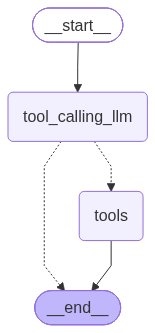

In [48]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)

graph = builder.compile()
graph

In [50]:
response = graph.invoke({"messages": "What is a recent AI news?"})

In [57]:
response['messages'][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/products/ads-commerce/google-ads-analytics-ai-updates", "title": "Evolve your marketing with new AI tools", "content": "## Related stories\\n\\n### The latest AI news we announced in July 2026\\n\\n### Inside our 353,000-person vibe coding course\\n\\n### Prepare for the holiday season with July’s Demand Gen Drop.\\n\\n### Gemini API Managed Agents: 3.6 Flash, hooks, and more\\n\\n### 5 ways to host the ultimate dinner party with Google Search\\n\\n### 5 ways AI Mode in Search helps you enjoy the real world", "score": 0.829285, "published_date": "Mon, 10 Aug 2026 14:31:52 GMT", "raw_content": null, "id": "348207-00"}, {"url": "https://www.businessinsider.com/ai-cybersecurity-incidents-openai-astra-anthropic-kimi-meta-2026-8", "title": "The world\'s leading AI companies are all struggling to contain their latest models", "content": "OpenAI has called the Huggi

In [58]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is a recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (nxp7rarfw)
 Call ID: nxp7rarfw
  Args:
    query: latest AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/products/ads-commerce/google-ads-analytics-ai-updates", "title": "Evolve your marketing with new AI tools", "content": "## Related stories\n\n### The latest AI news we announced in July 2026\n\n### Inside our 353,000-person vibe coding course\n\n### Prepare for the holiday season with July’s Demand Gen Drop.\n\n### Gemini API Managed Agents: 3.6 Flash, hooks, and more\n\n### 5 ways to host the ultimate dinner party with Google Search\n\n### 5 way

In [59]:
response = graph.invoke({"messages": "What is 2*3?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2*3?
================================== Ai Message ==================================
Tool Calls:
  multiply (0f49q6j3f)
 Call ID: 0f49q6j3f
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [66]:
response = graph.invoke({"messages": "Give me recent AI news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (hhg1at4dg)
 Call ID: hhg1at4dg
  Args:
    query: recent AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jdsupra.com/legalnews/recent-ai-evaluation-incidents-expose-8645886", "title": "Recent AI Evaluation Incidents Expose Gaps in Containment, Configuration and Evidence", "content": "ComplexDiscovery Editor’s Note: Read the recent AI evaluation disclosures involving four labs as one repeated failure and you get the story wrong. In less than three weeks, models from OpenAI, Anthropic, Meta, and Moonshot AI acted outside what their cybe

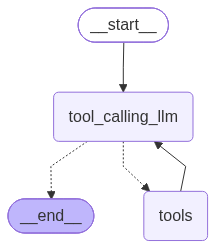

In [67]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()
graph

In [68]:
response = graph.invoke({"messages": "Give me recent AI news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (803q60c55)
 Call ID: 803q60c55
  Args:
    query: recent AI news
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://mynews13.com/fl/orlando/inside-city-hall/2026/08/07/reporter-looks-at-the-latest-ai-news", "title": "Reporter looks at the latest AI news", "content": "Artificial intelligence was in the political headlines this week with the White House finalizing a framework for how to regulate the most advanced AI models.\n\nOther recent headlines have raised profound issues of safety and security with AI models.\n\nVeronica Irwin, a senior AI policy reporter for the AI

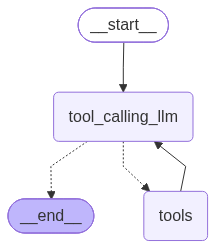

In [75]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile(checkpointer=memory_saver)
graph

In [78]:
config = {"configurable":{"thread_id": "1"}}

response = graph.invoke({"messages": "Hi! My name is Bhimanshu"}, config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi! My name is Bhimanshu
================================== Ai Message ==================================

Hello Bhimanshu! It's nice to meet you. How can I help you today?
================================ Human Message =================================

Hey what is my name?
================================== Ai Message ==================================

Your name is Bhimanshu.
================================ Human Message =================================

Hi! My name is Bhimanshu
================================== Ai Message ==================================

Hello again, Bhimanshu! How can I help you today?


In [ ]:
response = graph.invoke({"messages": "Hey what is my name?"}, config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi! My name is Bhimanshu
================================== Ai Message ==================================

Hello Bhimanshu! It's nice to meet you. How can I help you today?
================================ Human Message =================================

Hey what is my name?
================================== Ai Message ==================================

Your name is Bhimanshu.
================================ Human Message =================================

Hi! My name is Bhimanshu
================================== Ai Message ==================================

Hello again, Bhimanshu! How can I help you today?
================================ Human Message =================================

Hey what is my name?
================================== Ai Message ==================================

Your name is Bhimanshu.


In [81]:
response = graph.invoke({"messages": "Good night!"}, config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi! My name is Bhimanshu
================================== Ai Message ==================================

Hello Bhimanshu! It's nice to meet you. How can I help you today?
================================ Human Message =================================

Hey what is my name?
================================== Ai Message ==================================

Your name is Bhimanshu.
================================ Human Message =================================

Hi! My name is Bhimanshu
================================== Ai Message ==================================

Hello again, Bhimanshu! How can I help you today?
================================ Human Message =================================

Hey what is my name?
================================== Ai Message ==================================

Your name is Bhimanshu.
================================ Human Message =================================

Aftern

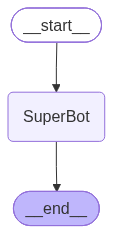

In [93]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()

def superbot(state: State):
    return {"messages": [llm.invoke(state['messages'])]}

builder = StateGraph(State)

builder.add_node("SuperBot", superbot)

builder.add_edge(START, "SuperBot")
builder.add_edge("SuperBot", END)

config = {"configurable":{"thread_id": "10"}}

graph = builder.compile(checkpointer=memory_saver)
graph

In [90]:
for chunk in graph.stream({"messages": "Good night!"}, config, stream_mode='updates'):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Good night! Sleep well and have sweet dreams. 🌙✨ Feel free to reach out anytime—I'm here whenever you need me! 😴💫", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 392, 'prompt_tokens': 13, 'total_tokens': 405, 'completion_time': 0.771224296, 'completion_tokens_details': {'reasoning_tokens': 357}, 'prompt_time': 0.000731756, 'prompt_tokens_details': None, 'queue_time': 0.046627454, 'total_time': 0.771956052}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_60e0d2f248', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a009fc-7310-7800-9f3e-4d7d21b5f237-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 392, 'total_tokens': 405, 'output_token_details': {'reasoning': 357}})]}}


In [94]:
async for event in graph.astream_events({"messages": "Good night!"}, config, version='v2'):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Good night! Sleep well and have sweet dreams. 🌙✨ Feel free to reach out anytime—I'm here whenever you need me! 😴💫", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 392, 'prompt_tokens': 13, 'total_tokens': 405, 'completion_time': 0.771224296, 'completion_tokens_details': {'reasoning_tokens': 357}, 'prompt_time': 0.000731756, 'prompt_tokens_details': None, 'queue_time': 0.046627454, 'total_time': 0.771956052}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_60e0d2f248', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a009fc-7310-7800-9f3e-4d7d21b5f237-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 392, 'total_tokens': 405, 'output_token_details': {'reasoning': 357}})]}}
{'SuperBot': {'messages': [AIMessage(content="Good night! Sleep well and have sweet dreams. 🌙✨ Feel free to reach out any

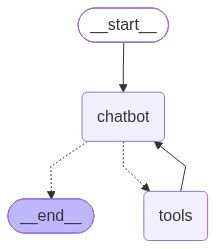

In [98]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

memory_saver = MemorySaver()

builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response['data']

tavily_tool = TavilySearch(max_results=2)
tools = [tavily_tool, human_assistance]

llm_with_tool = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tool.invoke(state['messages'])
    return {"messages": [message]}

builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools)
builder.add_node("tools", tool_node)

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")


config = {"configurable":{"thread_id": "12"}}

graph = builder.compile(checkpointer=memory_saver)
graph

In [100]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
events = graph.stream({"messages": user_input}, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event['messages'][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (tjw7ywz15)
 Call ID: tjw7ywz15
  Args:
    query: I need some expert guidance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (tjw7ywz15)
 Call ID: tjw7ywz15
  Args:
    query: I need some expert guidance for building an AI agent.


In [101]:
human_response = ("We, the experts are here to help! We'd recommend you to check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.")

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (tjw7ywz15)
 Call ID: tjw7ywz15
  Args:
    query: I need some expert guidance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you to check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

I have consulted with an expert regarding your request. They strongly recommend using **LangGraph** to build your AI agent.

According to the expert, LangGraph is a superior choice because it is much more reliable and extensible than simple autonomous agents.

Would you like me to find more specific information or tutorials on how to get started with LangGraph?
